In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
143,144,0,3,"Burke, Mr. Jeremiah",male,19.0,0,0,365222,6.7500,NaN,Q
112,113,0,3,"Barton, Mr. David John",male,22.0,0,0,324669,8.0500,NaN,S
561,562,0,3,"Sivic, Mr. Husein",male,40.0,0,0,349251,7.8958,NaN,S
395,396,0,3,"Johansson, Mr. Erik",male,22.0,0,0,350052,7.7958,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.5500,NaN,S
659,660,0,1,"Newell, Mr. Arthur Webster",male,58.0,0,2,35273,113.2750,D48,C
265,266,0,2,"Reeves, Mr. David",male,36.0,0,0,C.A. 17248,10.5000,NaN,S
238,239,0,2,"Pengelly, Mr. Frederick William",male,19.0,0,0,28665,10.5000,NaN,S
146,147,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [8]:
df.notnull().sum()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,714
SibSp,891
Parch,891
Ticket,891
Fare,891


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df["Survived"].unique()

array([0, 1])

In [12]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Age,177
Cabin,687
Embarked,2


In [16]:
missing_values[missing_values > 0].sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2


In [17]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

,Missing Count,Missing Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [18]:
df = df.drop_duplicates().copy()

In [19]:
df["Age"].median()

28.0

In [20]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [21]:
df["Embarked"].mode()

,Embarked
0,S


In [22]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [23]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [24]:
survival_rate = df["Survived"].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


In [25]:
df.groupby("Sex")["Survived"].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


In [26]:
df.groupby("Pclass")["Survived"].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


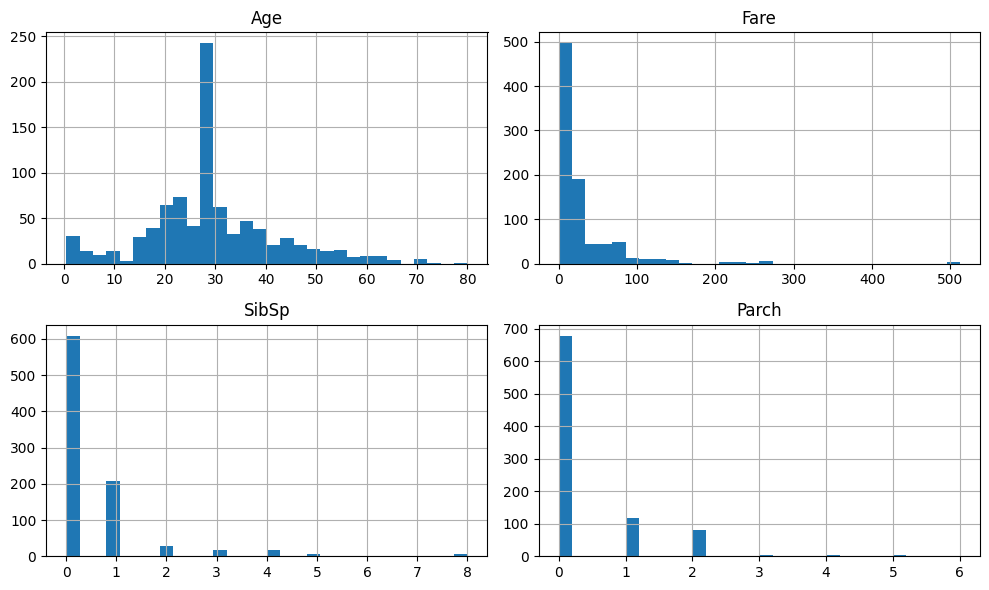

In [27]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

df[numeric_cols].hist(
    bins=30,
    figsize=(10, 6),
    layout=(2, 2)
)

plt.tight_layout()
plt.show()

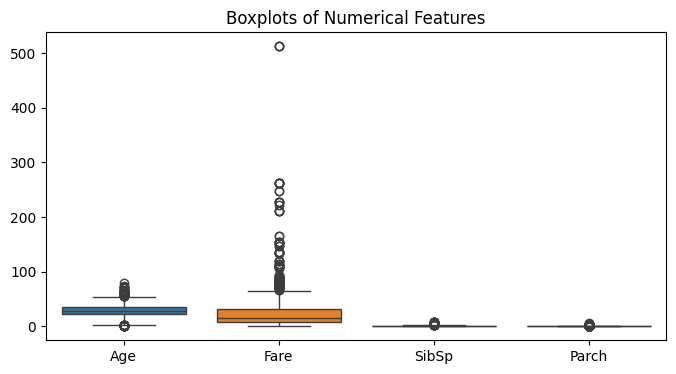

In [28]:
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

plt.figure(figsize=(8, 4))

sns.boxplot(data=df[numerical_cols])

plt.title("Boxplots of Numerical Features")
plt.show()

In [29]:
selected_cols = ["Age", "SibSp", "Parch", "Pclass", "Fare"]

df[selected_cols].corr()

,Age,SibSp,Parch,Pclass,Fare
Age,1.000000,-0.233296,-0.172482,-0.339898,0.096688
SibSp,-0.233296,1.000000,0.414838,0.083081,0.159651
Parch,-0.172482,0.414838,1.000000,0.018443,0.216225
Pclass,-0.339898,0.083081,0.018443,1.000000,-0.549500
Fare,0.096688,0.159651,0.216225,-0.549500,1.000000


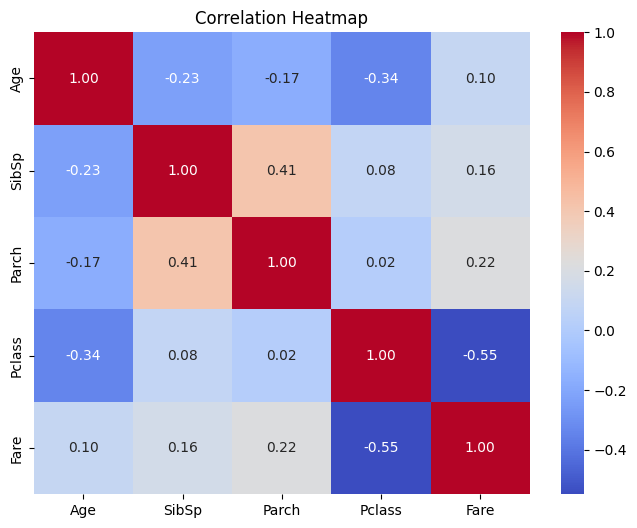

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["Age", "SibSp", "Parch", "Pclass", "Fare"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

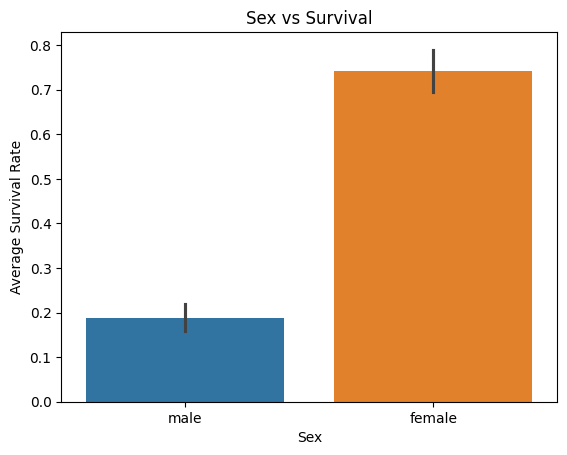

In [31]:
sns.barplot(
    x="Sex",
    y="Survived",
    data=df,
    hue="Sex",
    legend=False
)

plt.title("Sex vs Survival")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.show()

In [32]:
topFares = df.sort_values(
    by="Fare",
    ascending=False
)

In [34]:
top5 = topFares.head(5)

In [35]:
top5[["Name", "Sex", "Pclass", "Fare"]]

,Name,Sex,Pclass,Fare
679,"Cardeza, Mr. Thomas Drake Martinez",male,1,512.3292
258,"Ward, Miss. Anna",female,1,512.3292
737,"Lesurer, Mr. Gustave J",male,1,512.3292
88,"Fortune, Miss. Mabel Helen",female,1,263.0000
438,"Fortune, Mr. Mark",male,1,263.0000


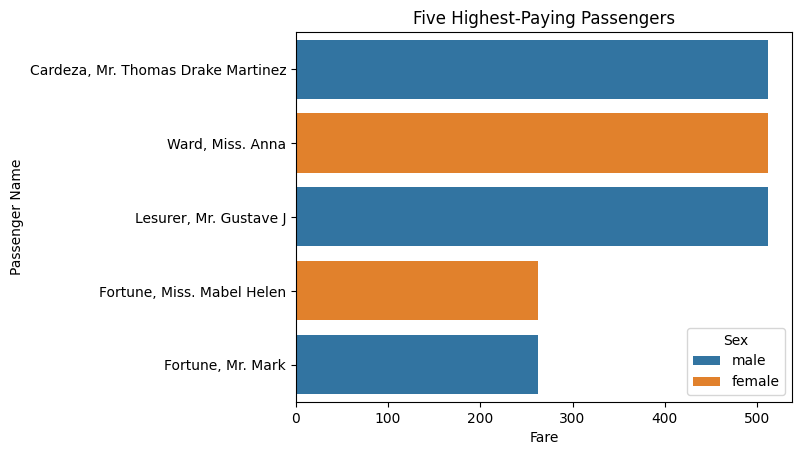

In [36]:
sns.barplot(
    x="Fare",
    y="Name",
    data=top5,
    hue="Sex"
)

plt.title("Five Highest-Paying Passengers")
plt.xlabel("Fare")
plt.ylabel("Passenger Name")
plt.show()